# Super-Resolution of 2D Darcy Flow using Fourier Neural Operators
**Scientific Machine Learning, Mines Paris PSL / SPEIT 2026**

**Darcy Flow PDE:**

$$-\nabla \cdot (a(x,y)\,\nabla u(x,y)) = f(x,y) \quad (x,y)\in [0,1]^2$$

$$u = 0 \quad \text{on } \partial[0,1]^2$$

**Operator learned:**

$$\mathcal{G}_\theta : \bigl(a(x,y),\, u_{LR}(x,y)\bigr) \longrightarrow u_{HR}(x,y) \quad (\times 16 \text{ upsampling})$$

**Models compared:** CNN | FNO-8 | FNO-16

## 0 - Installation

In [1]:
!pip install -q torch numpy scipy matplotlib pandas
print('packages ready')

packages ready


## 1 - Configuration

In [2]:
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from scipy.sparse import lil_matrix
from scipy.sparse.linalg import cg

# Hyperparameters
SEED = 42
N_TRAIN = 800
N_TEST = 200
HR_SIZE = 64 # HR 
LR_SIZE = 4  #LR
SCALE = HR_SIZE // LR_SIZE
BATCH_SIZE = 16
EPOCHS = 200      
LR_RATE = 1e-3    
FORCE_VALUE = 1.0

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

os.makedirs('results', exist_ok=True)
os.makedirs('data', exist_ok=True)

print(f'device  : {DEVICE}')
print(f'HR={HR_SIZE}  LR={LR_SIZE}  scale=x{SCALE}')
print(f'epochs={EPOCHS}  batch={BATCH_SIZE}  lr={LR_RATE}')

device  : cpu
HR=64  LR=4  scale=x16
epochs=200  batch=16  lr=0.001


## 2 - Dataset Generation

The coefficient field $a(x,y)$ is piecewise heterogeneous: $a \in \{3, 12\}$ (two-material, high/low permeability), generated via a thresholded Gaussian random field.

Each model receives a **2-channel input** $(B, 2, H, W)$:

- Channel 0 : $a(x,y)$ — the physical coefficient of the Darcy problem
- Channel 1 : $u_{LR}(x,y)$ — the low-resolution solution (bicubic ×16 upsampling)

Target: $u_{HR}(x,y)$ on a $64 \times 64$ grid.

In [3]:
def gaussian_filter(arr, sigma):
    size = max(1, int(4 * sigma + 0.5)) * 2 + 1
    x = np.arange(size) - size // 2
    k = np.exp(-x ** 2 / (2 * sigma ** 2))
    k /= k.sum()
    arr = np.apply_along_axis(lambda r: np.convolve(r, k, mode='same'), 0, arr)
    arr = np.apply_along_axis(lambda r: np.convolve(r, k, mode='same'), 1, arr)
    return arr


def generate_coefficient_field(n, smooth_sigma=3.0, threshold=0.0):
    noise = np.random.randn(n, n)
    smooth = gaussian_filter(noise, sigma=smooth_sigma)
    smooth = (smooth - smooth.mean()) / (smooth.std() + 1e-8)
    return np.where(smooth > threshold, 12.0, 3.0).astype(np.float64)


def solve_darcy(a, f_value=1.0):
    n = a.shape[0]
    h = 1.0 / (n - 1)
    N = (n - 2) * (n - 2)
    A = lil_matrix((N, N), dtype=np.float64)
    b = np.ones(N, dtype=np.float64) * f_value

    def idx(i, j):
        return (i - 1) * (n - 2) + (j - 1)

    for i in range(1, n - 1):
        for j in range(1, n - 1):
            row = idx(i, j)
            a_e = 0.5 * (a[i, j] + a[i + 1, j])
            a_w = 0.5 * (a[i, j] + a[i - 1, j])
            a_n = 0.5 * (a[i, j] + a[i, j + 1])
            a_s = 0.5 * (a[i, j] + a[i, j - 1])
            center = (a_e + a_w + a_n + a_s) / h ** 2
            A[row, row] = center
            if i + 1 < n - 1: A[row, idx(i + 1, j)] = -a_e / h ** 2
            if i - 1 > 0: A[row, idx(i - 1, j)] = -a_w / h ** 2
            if j + 1 < n - 1: A[row, idx(i, j + 1)] = -a_n / h ** 2
            if j - 1 > 0: A[row, idx(i, j - 1)] = -a_s / h ** 2

    u_int, _ = cg(A.tocsr(), b, atol=1e-10)
    u = np.zeros((n, n), dtype=np.float64)
    for i in range(1, n - 1):
        for j in range(1, n - 1):
            u[i, j] = u_int[idx(i, j)]
    return u.astype(np.float32)


def generate_dataset(n_samples, hr_size):
    coeffs, solutions = [], []
    for k in range(n_samples):
        a = generate_coefficient_field(hr_size)
        u = solve_darcy(a, FORCE_VALUE)
        coeffs.append(a)
        solutions.append(u)
        if (k + 1) % 200 == 0:
            print(f'  {k + 1}/{n_samples}')
    return np.stack(coeffs).astype(np.float32), np.stack(solutions)


if os.path.exists('data/sol_train.npy'):
    print('loading dataset from disk...')
    coeff_train = np.load('data/coeff_train.npy')
    sol_train = np.load('data/sol_train.npy')
    coeff_test = np.load('data/coeff_test.npy')
    sol_test = np.load('data/sol_test.npy')
else:
    print('generating train set...')
    coeff_train, sol_train = generate_dataset(N_TRAIN, HR_SIZE)
    print('generating test set...')
    coeff_test, sol_test = generate_dataset(N_TEST, HR_SIZE)
    np.save('data/coeff_train.npy', coeff_train)
    np.save('data/sol_train.npy', sol_train)
    np.save('data/coeff_test.npy', coeff_test)
    np.save('data/sol_test.npy', sol_test)
    print('dataset saved to disk')

print(f'train : coeff={coeff_train.shape}  sol={sol_train.shape}')
print(f'test  : coeff={coeff_test.shape}   sol={sol_test.shape}')

loading dataset from disk...
train : coeff=(800, 64, 64)  sol=(800, 64, 64)
test  : coeff=(200, 64, 64)   sol=(200, 64, 64)


## 3 - Input Construction

In [4]:
u_mean = sol_train.mean()
u_std = sol_train.std() + 1e-8
a_mean = float(coeff_train.mean())
a_std = float(coeff_train.std()) + 1e-8

def normalize_u(u): return (u - u_mean) / u_std
def denormalize_u(u): return u * u_std + u_mean

sol_train_n = normalize_u(sol_train)
sol_test_n = normalize_u(sol_test)


def build_inputs(solutions, coeffs):
    x = torch.tensor(solutions[:, None], dtype=torch.float32)
    a = torch.tensor(coeffs[:, None], dtype=torch.float32)
    lr = F.interpolate(x, size=(LR_SIZE, LR_SIZE), mode='area')
    lr_up = F.interpolate(lr, size=(HR_SIZE, HR_SIZE),
                          mode='bicubic', align_corners=False)
    a_norm = (a - a_mean) / a_std
    inp = torch.cat([a_norm, lr_up], dim=1).numpy()
    return inp, x.numpy()[:, 0]

x_train, y_train = build_inputs(sol_train_n, coeff_train)
x_test, y_test = build_inputs(sol_test_n, coeff_test)

print(f'a : mean={a_mean:.3f}  std={a_std:.3f}')
print(f'u : mean={u_mean:.4f}  std={u_std:.4f}')
print(f'input shape : {x_train.shape}  (B, 2, H, W)')
print(f'target shape: {y_train.shape}  (B, H, W)')

a : mean=7.493  std=4.500
u : mean=0.0054  std=0.0036
input shape : (800, 2, 64, 64)  (B, 2, H, W)
target shape: (800, 64, 64)  (B, H, W)


## 4 - Dataset Visualization

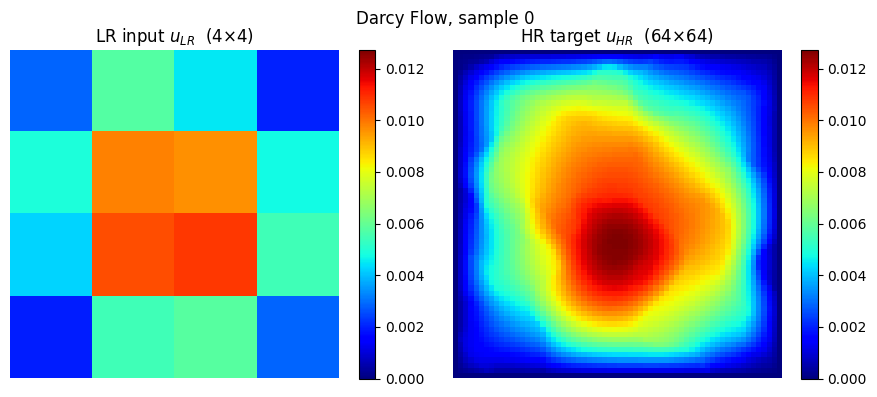

In [5]:
lr_native = denormalize_u(
    F.interpolate(
        torch.tensor(sol_train_n[0:1, None], dtype=torch.float32),
        size=(LR_SIZE, LR_SIZE), mode='area'
    )[0, 0].numpy()
)
hr_vis = denormalize_u(y_train[0])
vmin, vmax = min(lr_native.min(), hr_vis.min()), max(lr_native.max(), hr_vis.max())

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle('Darcy Flow, sample 0', fontsize=12)

im1 = axes[0].imshow(lr_native, cmap='jet', vmin=vmin, vmax=vmax,
                     interpolation='nearest')
axes[0].set_title(f'LR input $u_{{LR}}$  ({LR_SIZE}×{LR_SIZE})')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(hr_vis, cmap='jet', vmin=vmin, vmax=vmax)
axes[1].set_title(f'HR target $u_{{HR}}$  ({HR_SIZE}×{HR_SIZE})')
plt.colorbar(im2, ax=axes[1])

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('results/dataset_example.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 - PyTorch Dataset and Metrics

In [6]:
class DarcyDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y[:, None], dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        return self.x[i], self.y[i]


train_ds = DarcyDataset(x_train, y_train)
test_ds = DarcyDataset(x_test, y_test)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


def relative_l2(pred, target):
    num = torch.norm(pred - target)
    den = torch.norm(target) + 1e-8
    return (num / den).item()


def rmse(pred, target):
    return torch.sqrt(torch.mean((pred - target) ** 2)).item()


def psnr(pred, target):
    p_d = denormalize_u(pred.detach().cpu().numpy())
    t_d = denormalize_u(target.detach().cpu().numpy())
    dr = t_d.max() - t_d.min()
    return 20 * np.log10(dr / (np.sqrt(np.mean((p_d - t_d) ** 2)) + 1e-12))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 6 - Architecture

Both models receive the 2-channel input $[a(x,y),\, u_{LR}(x,y)]$.
Including $a$ gives each model direct access to the physical structure of the problem.

### FNO-2D
The spatial grid $(x_{coord}, y_{coord})$ is appended, giving a 4-feature token per point:
$$[a,\; u_{LR},\; x_{coord},\; y_{coord}] \quad \Rightarrow \quad \text{fc0} : \mathbb{R}^4 \to \mathbb{R}^W$$
Fourier layer:
$$v_{t+1}(x) = \sigma\left(W v_t + \mathcal{F}^{-1}[R \cdot \mathcal{F}(v_t)](x)\right)$$
FNO-8 uses $k_{max}=8$ modes, FNO-16 uses $k_{max}=16$.

### CNN Baseline (SRCNN)
Same 2-channel input, purely local convolutions — no global spectral operations.

In [7]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, modes1, modes2):
        super().__init__()
        self.modes1 = modes1
        self.modes2 = modes2
        s = 1.0 / (in_ch * out_ch)
        self.w1 = nn.Parameter(
            s * torch.randn(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat))
        self.w2 = nn.Parameter(
            s * torch.randn(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat))

    def forward(self, x):
        B = x.shape[0]
        xf = torch.fft.rfft2(x)
        out = torch.zeros(B, self.w1.shape[1],
                          x.size(-2), x.size(-1) // 2 + 1,
                          dtype=torch.cfloat, device=x.device)
        m1, m2 = self.modes1, self.modes2
        out[:, :, :m1, :m2] = torch.einsum(
            'bixy,ioxy->boxy', xf[:, :, :m1, :m2], self.w1)
        out[:, :, -m1:, :m2] = torch.einsum(
            'bixy,ioxy->boxy', xf[:, :, -m1:, :m2], self.w2)
        return torch.fft.irfft2(out, s=(x.size(-2), x.size(-1)))


class FNO2d(nn.Module):
    
    def __init__(self, modes1=12, modes2=12, width=32):
        super().__init__()
        self.fc0 = nn.Linear(4, width)   # (a, u_LR, x, y) -> width
        self.conv0 = SpectralConv2d(width, width, modes1, modes2)
        self.conv1 = SpectralConv2d(width, width, modes1, modes2)
        self.conv2 = SpectralConv2d(width, width, modes1, modes2)
        self.conv3 = SpectralConv2d(width, width, modes1, modes2)
        self.w0 = nn.Conv2d(width, width, 1)
        self.w1 = nn.Conv2d(width, width, 1)
        self.w2 = nn.Conv2d(width, width, 1)
        self.w3 = nn.Conv2d(width, width, 1)
        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, 1)

    def get_grid(self, shape, device):
        B, _, H, W = shape
        gx = torch.linspace(0, 1, H, device=device)
        gy = torch.linspace(0, 1, W, device=device)
        gx = gx.reshape(1, H, 1, 1).repeat(B, 1, W, 1)
        gy = gy.reshape(1, 1, W, 1).repeat(B, H, 1, 1)
        return torch.cat((gx, gy), dim=-1)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        # x shape: (B, 2, H, W) -> permute -> (B, H, W, 2)
        # grid shape: (B, H, W, 2)
        # cat -> (B, H, W, 4) : [a, u_LR, x_coord, y_coord]
        x = torch.cat((x.permute(0, 2, 3, 1), grid), dim=-1)
        x = self.fc0(x).permute(0, 3, 1, 2)
        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))
        x = F.gelu(self.conv3(x) + self.w3(x))
        x = x.permute(0, 2, 3, 1)
        x = F.gelu(self.fc1(x))
        return self.fc2(x).permute(0, 3, 1, 2)


class SRCNN(nn.Module):
    """CNN baseline -- local conv only, no spectral operations."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 64, 9, padding=4), nn.ReLU(),
            nn.Conv2d(64, 64, 5, padding=2), nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1))

    def forward(self, x):
        return self.net(x)


# sanity check
_x = torch.randn(2, 2, HR_SIZE, HR_SIZE)
_f8 = FNO2d(8, 8, 32)
_f16 = FNO2d(16, 16, 32)
_cnn = SRCNN()
print(f'FNO-8   {tuple(_x.shape)} -> {tuple(_f8(_x).shape)}'
      f'  params={count_params(_f8):,}')
print(f'FNO-16  {tuple(_x.shape)} -> {tuple(_f16(_x).shape)}'
      f'  params={count_params(_f16):,}')
print(f'CNN     {tuple(_x.shape)} -> {tuple(_cnn(_x).shape)}'
      f'  params={count_params(_cnn):,}')

FNO-8   (2, 2, 64, 64) -> (2, 1, 64, 64)  params=533,025
FNO-16  (2, 2, 64, 64) -> (2, 1, 64, 64)  params=2,105,889
CNN     (2, 2, 64, 64) -> (2, 1, 64, 64)  params=131,649


## 7 - Training

**Loss:** MSE  
**Optimizer:** Adam + StepLR halved every 50 epochs

In [17]:
def train_model(model, name):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LR_RATE, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=50, gamma=0.5)
    criterion = nn.MSELoss()

    train_losses, test_losses = [], []
    best_loss, best_state = float('inf'), None
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        tr = 0.0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()

            loss = criterion(model(x), y)

            loss.backward()
            optimizer.step()

            tr += loss.item() * len(x)

        tr /= N_TRAIN

        scheduler.step()

        model.eval()
        te, rl2_vals, psnr_vals = 0.0, [], []

        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)

                p = model(x)

                te += criterion(p, y).item() * len(x)

                rl2_vals.append(
                    relative_l2(p.cpu(), y.cpu())
                )

                psnr_vals.append(
                    psnr(p.cpu(), y.cpu())
                )

        te /= N_TEST

        te_rl2 = np.mean(rl2_vals)
        te_psnr = np.mean(psnr_vals)

        train_losses.append(tr)
        test_losses.append(te)

        if te < best_loss:
            best_loss = te
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

        if epoch % 50 == 0 or epoch == 1:
            print(f'  [{name}] epoch {epoch:3d}/{EPOCHS}'
                  f'  train={tr:.6f}'
                  f'  test={te:.6f}'
                  f'  RL2={te_rl2:.4f}'
                  f'  PSNR={te_psnr:.2f}dB'
                  f'  lr={optimizer.param_groups[0]["lr"]:.1e}'
                  f'  t={time.time() - t0:.0f}s')

    model.load_state_dict(best_state)

    print(f'  [{name}] best test MSE={best_loss:.6f}')

    return model, train_losses, test_losses

In [ ]:
print('CNN Baseline: \n')
cnn, cnn_tr, cnn_te = train_model(SRCNN(), 'CNN')
torch.save(cnn.state_dict(), 'data/cnn.pt')

print()
print('FNO-8  (kmax=8): \n')
fno8, fno8_tr, fno8_te = train_model(FNO2d(8, 8, 32), 'FNO-8')
torch.save(fno8.state_dict(), 'data/fno8.pt')

print()
print('FNO-16  (kmax=16): \n')
fno16, fno16_tr, fno16_te = train_model(FNO2d(16, 16, 32), 'FNO-16')
torch.save(fno16.state_dict(), 'data/fno16.pt')

np.save('data/cnn_losses.npy',  np.array([cnn_tr,  cnn_te]))
np.save('data/fno8_losses.npy', np.array([fno8_tr, fno8_te]))
np.save('data/fno16_losses.npy',np.array([fno16_tr,fno16_te]))

In [ ]:
# Run this cell after kernel restart to reload trained models (skips retraining)
if os.path.exists('data/cnn.pt'):
    cnn   = SRCNN().to(DEVICE)
    fno8  = FNO2d(8,  8,  32).to(DEVICE)
    fno16 = FNO2d(16, 16, 32).to(DEVICE)
    cnn.load_state_dict(  torch.load('data/cnn.pt',   map_location=DEVICE))
    fno8.load_state_dict( torch.load('data/fno8.pt',  map_location=DEVICE))
    fno16.load_state_dict(torch.load('data/fno16.pt', map_location=DEVICE))
    cnn.eval(); fno8.eval(); fno16.eval()

    if os.path.exists('data/cnn_losses.npy'):
        _l = np.load('data/cnn_losses.npy')
        cnn_tr,  cnn_te  = _l[0].tolist(), _l[1].tolist()
        _l = np.load('data/fno8_losses.npy')
        fno8_tr, fno8_te = _l[0].tolist(), _l[1].tolist()
        _l = np.load('data/fno16_losses.npy')
        fno16_tr,fno16_te= _l[0].tolist(), _l[1].tolist()

    print('models loaded from disk')
else:
    print('no saved models — run the training cell above first')

## 8 - Results

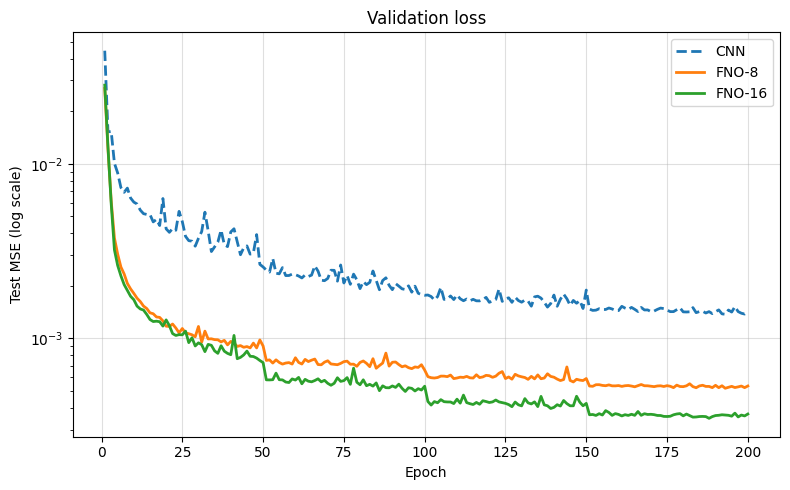

In [19]:
ep_range = range(1, EPOCHS + 1)
plt.figure(figsize=(8, 5))
plt.semilogy(ep_range, cnn_te, label='CNN', lw=2, ls='--')
plt.semilogy(ep_range, fno8_te, label='FNO-8', lw=2)
plt.semilogy(ep_range, fno16_te, label='FNO-16', lw=2)
plt.xlabel('Epoch')
plt.ylabel('Test MSE (log scale)')
plt.title('Validation loss')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('results/loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
def evaluate_model(model):
    model.eval()
    model.to(DEVICE)
    rl2, rm, rp = [], [], []
    t0 = time.time()
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            p = model(x)
            rl2.append(relative_l2(p.cpu(), y.cpu()))
            rm.append(rmse(p.cpu(), y.cpu()))
            rp.append(psnr(p.cpu(), y.cpu()))
    elapsed = time.time() - t0
    return {
        'Relative L2': np.mean(rl2),
        'RMSE': np.mean(rm),
        'PSNR': np.mean(rp),
        'Inference (ms)': elapsed / N_TEST * 1000,
    }


results = {
    'CNN': evaluate_model(cnn),
    'FNO-8': evaluate_model(fno8),
    'FNO-16': evaluate_model(fno16),
}

param_map = {
    'CNN': count_params(cnn),
    'FNO-8': count_params(fno8),
    'FNO-16': count_params(fno16),
}

df = pd.DataFrame(results).T
df.insert(0, 'Params', [param_map[m] for m in df.index])
df = df.sort_values('Relative L2')
df.to_csv('results/metrics.csv')

print('=' * 65)
print('QUANTITATIVE RESULTS : test set')
print('=' * 65)
print(df.to_string())
print(f'\nbest model : {df.index[0]}')

QUANTITATIVE RESULTS : test set
         Params  Relative L2      RMSE       PSNR  Inference (ms)
FNO-16  2105889     0.018792  0.018692  45.628136        0.106151
FNO-8    533025     0.022886  0.022767  43.914528        0.109155
CNN      131649     0.037329  0.037126  39.669212        0.114341

best model : FNO-16


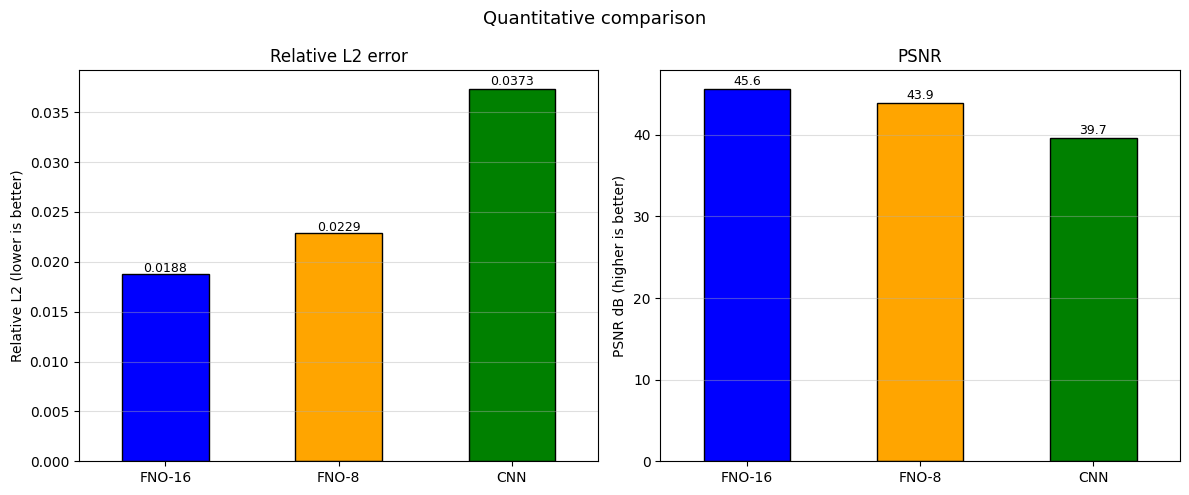

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Quantitative comparison', fontsize=13)

colors = ['blue', 'orange', 'green']

df['Relative L2'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_ylabel('Relative L2 (lower is better)')
axes[0].set_title('Relative L2 error')
axes[0].grid(axis='y', alpha=0.4)
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * 1.01,
                 f'{bar.get_height():.4f}',
                 ha='center', fontsize=9)

df['PSNR'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_ylabel('PSNR dB (higher is better)')
axes[1].set_title('PSNR')
axes[1].grid(axis='y', alpha=0.4)
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * 1.01,
                 f'{bar.get_height():.1f}',
                 ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Qualitative comparison

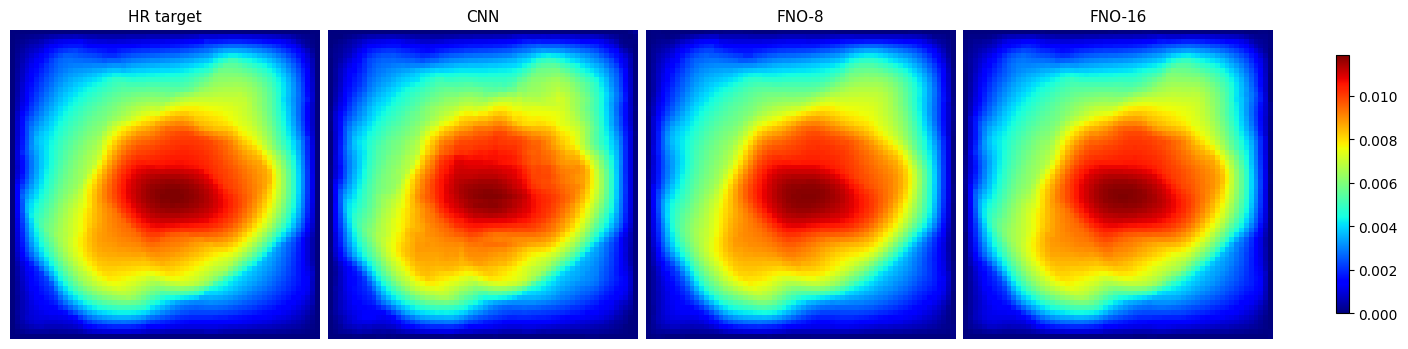

In [24]:
def get_preds(idx):
    x, y = test_ds[idx]
    xb = x[None].to(DEVICE)

    with torch.no_grad():
        pc = cnn(xb).cpu()[0, 0].numpy()
        pf8 = fno8(xb).cpu()[0, 0].numpy()
        pf16 = fno16(xb).cpu()[0, 0].numpy()

    return pc, pf8, pf16, y[0].numpy()


idx = 0
pc, pf8, pf16, hr = get_preds(idx)

imgs = [
    denormalize_u(hr),
    denormalize_u(pc),
    denormalize_u(pf8),
    denormalize_u(pf16)
]

titles = [
    "HR target",
    "CNN",
    "FNO-8",
    "FNO-16"
]

vmin = imgs[0].min()
vmax = imgs[0].max()

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), constrained_layout=True)

for ax, img, title in zip(axes, imgs, titles):
    im = ax.imshow(img, cmap="jet", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

fig.colorbar(im, ax=axes, shrink=0.8, location="right")

plt.savefig("results/qualitative_clean.png", dpi=200, bbox_inches="tight")
plt.show()

### Error maps

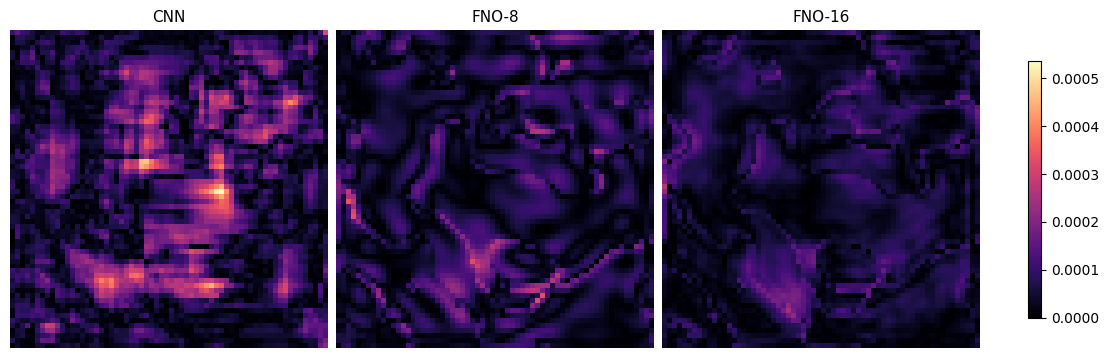

In [25]:
pc, pf8, pf16, hr = get_preds(0)

hr_d = denormalize_u(hr)

errors = {
    "CNN": np.abs(denormalize_u(pc) - hr_d),
    "FNO-8": np.abs(denormalize_u(pf8) - hr_d),
    "FNO-16": np.abs(denormalize_u(pf16) - hr_d),
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(11, 3.5),
    constrained_layout=True
)

vmax_e = max(err.max() for err in errors.values())

for ax, (name, err) in zip(axes, errors.items()):
    im = ax.imshow(
        err,
        cmap="magma",
        vmin=0,
        vmax=vmax_e
    )

    ax.set_title(name, fontsize=11)
    ax.axis("off")

fig.colorbar(
    im,
    ax=axes,
    shrink=0.8,
    location="right"
)

plt.savefig(
    "results/error_maps.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 9 - Zero-shot Resolution Generalization

The FNO learns a **continuous operator** and should generalize to resolutions unseen during training.  
All models are trained on **64 -> 4 (x16)**. We test on three out-of-distribution configurations:

| Config | HR test | LR test | Scale | What is tested |
|--------|---------|---------|-------|----------------|
| ZS-1 | 128 | 4 | x32 | Finer HR grid (higher output resolution) |
| ZS-2 | 64 | 8 | x8 | Coarser LR input (less information at input) |
| ZS-3 | 128 | 8 | x16 | Same scale ratio, double spatial resolution |

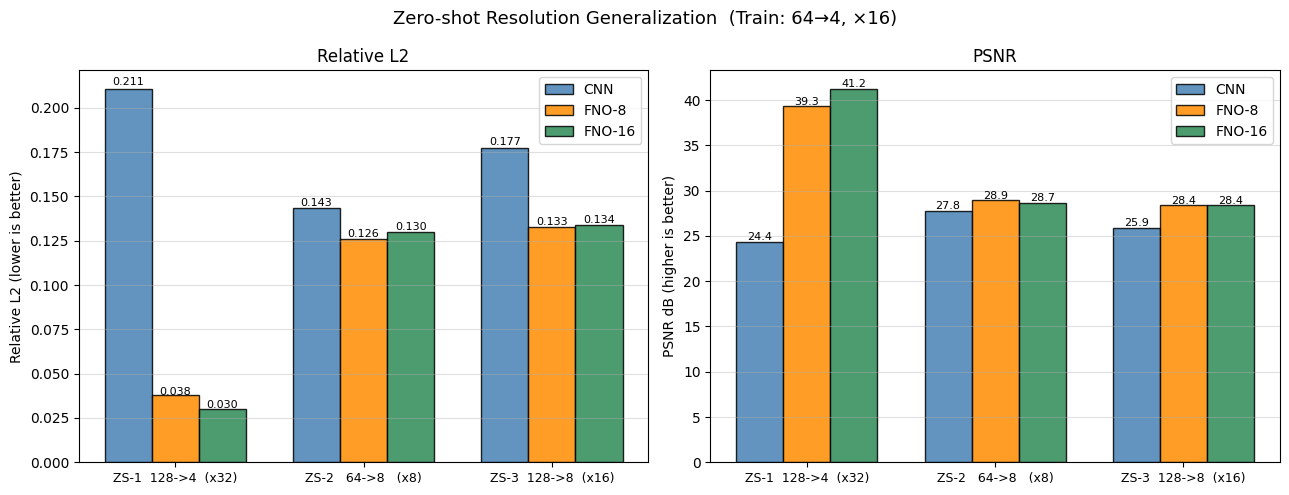

In [ ]:
config_labels = [c[0].strip() for c in zs_configs]
model_names = list(model_dict.keys())
bar_colors = ['steelblue', 'darkorange', 'seagreen']

x = np.arange(len(config_labels))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Zero-shot Resolution Generalization  (Train: 64→4, ×16)', fontsize=13)

for i, mname in enumerate(model_names):
    rl2_vals  = [zs_results[(c, mname)]['RL2']  for c in config_labels]
    psnr_vals = [zs_results[(c, mname)]['PSNR'] for c in config_labels]

    bars = axes[0].bar(x + i * width, rl2_vals, width, label=mname,
                       color=bar_colors[i], edgecolor='black', alpha=0.85)
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                     f'{bar.get_height():.3f}', ha='center', fontsize=8)

    bars = axes[1].bar(x + i * width, psnr_vals, width, label=mname,
                       color=bar_colors[i], edgecolor='black', alpha=0.85)
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.005,
                     f'{bar.get_height():.1f}', ha='center', fontsize=8)

for ax, ylabel, title in zip(
    axes,
    ['Relative L2 (lower is better)', 'PSNR dB (higher is better)'],
    ['Relative L2', 'PSNR']
):
    ax.set_xticks(x + width)
    ax.set_xticklabels(config_labels, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('results/zero_shot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def build_zs_dataset(hr_test, lr_test, n=50):
    inputs, targets = [], []
    for _ in range(n):
        coeff = generate_coefficient_field(hr_test)
        u_hr = solve_darcy(coeff)
        coeff_norm = (coeff.astype(np.float32) - a_mean) / a_std
        u_norm = normalize_u(u_hr)
        u_tensor = torch.tensor(u_norm[None, None], dtype=torch.float32)
        u_lr = F.interpolate(u_tensor, size=(lr_test, lr_test), mode='area')
        u_lr_up = F.interpolate(
            u_lr, size=(hr_test, hr_test), mode='bicubic', align_corners=False
        )[0, 0].numpy()
        inputs.append(np.stack([coeff_norm, u_lr_up], axis=0))
        targets.append(u_norm)
    return (
        torch.tensor(np.array(inputs), dtype=torch.float32),
        torch.tensor(np.array(targets)[:, None], dtype=torch.float32)
    )


def eval_zs(model, inputs_zs, targets_zs):
    model.eval()
    rl2_vals, psnr_vals = [], []
    with torch.no_grad():
        for i in range(0, len(inputs_zs), BATCH_SIZE):
            x = inputs_zs[i:i+BATCH_SIZE].to(DEVICE)
            y = targets_zs[i:i+BATCH_SIZE]
            pred = model(x).cpu()
            rl2_vals.append(relative_l2(pred, y))
            psnr_vals.append(psnr(pred, y))
    return float(np.mean(rl2_vals)), float(np.mean(psnr_vals))


N_ZERO = 50
zs_configs = [
    ('ZS-1  128->4  (x32)', 128, 4),
    ('ZS-2   64->8   (x8)',  64, 8),
    ('ZS-3  128->8  (x16)', 128, 8),
]
model_dict = {'CNN': cnn, 'FNO-8': fno8, 'FNO-16': fno16}
zs_results = {}   # {(config_label, model_name): {'RL2': float, 'PSNR': float}}

print(f'Train: {HR_SIZE}->{LR_SIZE} (x{SCALE})\n')
print(f'{"Config":<24}  {"Model":<8}  {"RL2":>6}  {"PSNR":>8}')
print('-' * 54)

for label, hr_t, lr_t in zs_configs:
    print(f'\nBuilding dataset  {label} ...')
    inp_zs, tgt_zs = build_zs_dataset(hr_t, lr_t, N_ZERO)
    for mname, model in model_dict.items():
        rl2, ps = eval_zs(model, inp_zs, tgt_zs)
        zs_results[(label.strip(), mname)] = {'RL2': rl2, 'PSNR': ps}
        print(f'  {label:<24}  {mname:<8}  {rl2:.4f}  {ps:.2f} dB')

# sauvegarde CSV 
with open('results/zero_shot_metrics.csv', 'w') as f:
    f.write('Config,Model,RL2,PSNR\n')
    for (cfg, mdl), v in zs_results.items():
        f.write(f'{cfg},{mdl},{v["RL2"]:.6f},{v["PSNR"]:.4f}\n')

# tableaux résumés
model_names_list  = list(model_dict.keys())
config_names_list = [c[0].strip() for c in zs_configs]

print('\n\nSUMMARY -- Relative L2')
print(f'{"Config":<25}' + ''.join(f'{m:>10}' for m in model_names_list))
for cfg in config_names_list:
    print(f'{cfg:<25}' + ''.join(
        f'{zs_results[(cfg, m)]["RL2"]:>10.4f}' for m in model_names_list))

print('\nSUMMARY -- PSNR (dB)')
print(f'{"Config":<25}' + ''.join(f'{m:>10}' for m in model_names_list))
for cfg in config_names_list:
    print(f'{cfg:<25}' + ''.join(
        f'{zs_results[(cfg, m)]["PSNR"]:>10.2f}' for m in model_names_list))

Train: 64->4 (x16)

Config                    Model        RL2      PSNR
------------------------------------------------------

Building dataset  ZS-1  128->4  (x32) ...
  ZS-1  128->4  (x32)       CNN       0.2106  24.37 dB
  ZS-1  128->4  (x32)       FNO-8     0.0378  39.30 dB
  ZS-1  128->4  (x32)       FNO-16    0.0303  41.22 dB

Building dataset  ZS-2   64->8   (x8) ...
  ZS-2   64->8   (x8)       CNN       0.1434  27.80 dB
  ZS-2   64->8   (x8)       FNO-8     0.1261  28.91 dB
  ZS-2   64->8   (x8)       FNO-16    0.1297  28.67 dB

Building dataset  ZS-3  128->8  (x16) ...
  ZS-3  128->8  (x16)       CNN       0.1773  25.92 dB
  ZS-3  128->8  (x16)       FNO-8     0.1327  28.43 dB
  ZS-3  128->8  (x16)       FNO-16    0.1337  28.37 dB


SUMMARY -- Relative L2
Config                          CNN     FNO-8    FNO-16
ZS-1  128->4  (x32)          0.2106    0.0378    0.0303
ZS-2   64->8   (x8)          0.1434    0.1261    0.1297
ZS-3  128->8  (x16)          0.1773    0.1327    0.1337

### Qualitative zero-shot comparison

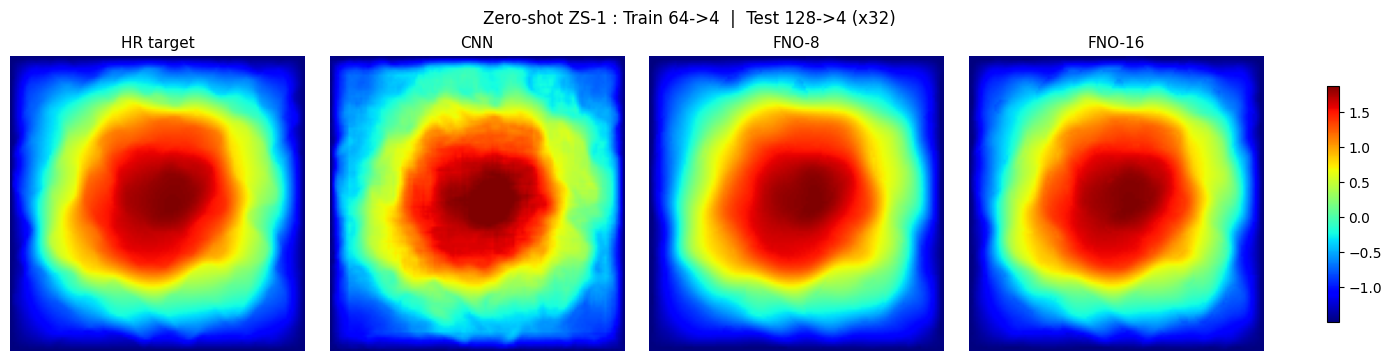

In [22]:
def get_zs_sample(hr_t, lr_t, seed=0):
    """Generate one reproducible sample for a given (hr, lr) config."""
    rng_state = np.random.get_state()
    np.random.seed(seed)

    coeff   = generate_coefficient_field(hr_t)
    u_hr    = solve_darcy(coeff)
    coeff_n = (coeff.astype(np.float32) - a_mean) / a_std
    u_norm  = normalize_u(u_hr)

    u_t  = torch.tensor(u_norm[None, None], dtype=torch.float32)
    u_lr = F.interpolate(u_t, size=(lr_t, lr_t), mode='area')
    u_up = F.interpolate(u_lr, size=(hr_t, hr_t),
                         mode='bicubic', align_corners=False)[0, 0].numpy()
    inp  = torch.tensor(np.stack([coeff_n, u_up])[None], dtype=torch.float32)

    np.random.set_state(rng_state)
    return inp, u_norm


# ZS-1 only : Train 64->4  |  Test 128->4 (x32)
inp, u_norm = get_zs_sample(hr_t=128, lr_t=4, seed=0)

with torch.no_grad():
    p_cnn   = cnn(inp.to(DEVICE)).cpu()[0, 0].numpy()
    p_fno8  = fno8(inp.to(DEVICE)).cpu()[0, 0].numpy()
    p_fno16 = fno16(inp.to(DEVICE)).cpu()[0, 0].numpy()

imgs   = [u_norm, p_cnn, p_fno8, p_fno16]
titles = ['HR target', 'CNN', 'FNO-8', 'FNO-16']
vmin, vmax = u_norm.min(), u_norm.max()

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), constrained_layout=True)
fig.suptitle('Zero-shot ZS-1 : Train 64->4  |  Test 128->4 (x32)', fontsize=12)

for ax, img, title in zip(axes, imgs, titles):
    im = ax.imshow(img, cmap='jet', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

fig.colorbar(im, ax=axes, shrink=0.8, location='right')
plt.savefig('results/zero_shot_qualitative.png', dpi=200, bbox_inches='tight')
plt.show()